# Notebook 1 — XOR Encrypt / Decrypt

**Input:**  `Train_Test_IoT_Modbus.csv` (original)  
**Outputs:** `data_xor_encrypted.csv` + `data_xor_decrypted.csv`

---
### How XOR works here
```
Encrypt:  register_value  XOR  key  =  encrypted_value
Decrypt:  encrypted_value XOR  key  =  original_value   (XOR is self-inverse)
```
The key stream is generated from a shared PRNG seed.  
Anyone without the seed cannot reverse the encryption.

---

In [34]:
import pandas as pd
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
INPUT_FILE       = 'Train_Test_IoT_Modbus.csv'
ENCRYPTED_FILE   = 'data_xor_encrypted64onecell.csv'
DECRYPTED_FILE   = 'data_xor_decrypted64onecell.csv'

SHARED_SECRET    = 999          # PRNG seed — acts as the secret key
MODBUS_MAX       = 2**64 - 1     # 64-bit register ceiling

# Modbus register columns — only these get perturbed
FC_COLS = [
    'FC1_Read_Input_Register',
    'FC2_Read_Discrete_Value',
    'FC3_Read_Holding_Register',
    'FC4_Read_Coil'
]

print('Config loaded.')
print(f'  Secret seed  : {SHARED_SECRET}')
print(f'  Key range    : 0 – {MODBUS_MAX}')
print(f'  Columns      : {FC_COLS}')

Config loaded.
  Secret seed  : 999
  Key range    : 0 – 18446744073709551615
  Columns      : ['FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil']


## Step 1 — Load Original Data

In [35]:
df_original = pd.read_csv(INPUT_FILE)

print(f'Loaded: {INPUT_FILE}')
print(f'Shape : {df_original.shape}')
print(f'\nFirst 3 rows (FC columns):')
print(df_original[FC_COLS].head(3).to_string())

Loaded: Train_Test_IoT_Modbus.csv
Shape : (31106, 8)

First 3 rows (FC columns):
   FC1_Read_Input_Register  FC2_Read_Discrete_Value  FC3_Read_Holding_Register  FC4_Read_Coil
0                    49389                    52921                      25770          13625
1                    49389                    52921                      25770          13625
2                    49389                    52921                      25770          13625


In [36]:
print('='*70)
print('FC_Read_64bit_Original — 16-bit to 64-bit Conversion (Before Encryption)')
print('='*70)
print()

# Extract 4 columns as uint16 (native Modbus type)
fc1_orig = df_original['FC1_Read_Input_Register'].values.astype(np.uint16)
fc2_orig = df_original['FC2_Read_Discrete_Value'].values.astype(np.uint16)
fc3_orig = df_original['FC3_Read_Holding_Register'].values.astype(np.uint16)
fc4_orig = df_original['FC4_Read_Coil'].values.astype(np.uint16)

# Pack 4 × 16-bit values into 1 × 64-bit value
# FC1 (bits 48-63), FC2 (bits 32-47), FC3 (bits 16-31), FC4 (bits 0-15)
X_64bit_original = (fc1_orig.astype(np.uint64) << 48) | (fc2_orig.astype(np.uint64) << 32) | (fc3_orig.astype(np.uint64) << 16) | fc4_orig.astype(np.uint64)

# Display conversion table for first 10 rows
conversion_table = pd.DataFrame({
    'Row': range(len(df_original))[:10],
    'FC1 (16-bit)': fc1_orig[:10],
    'FC2 (16-bit)': fc2_orig[:10],
    'FC3 (16-bit)': fc3_orig[:10],
    'FC4 (16-bit)': fc4_orig[:10],
    'Combined 64-bit': X_64bit_original[:10],
})

print(conversion_table.to_string(index=False))
print()
print(f'Total rows converted: {len(X_64bit_original):,}')
print(f'Data type after packing: {X_64bit_original.dtype}')
print(f'Value range: {X_64bit_original.min():,} to {X_64bit_original.max():,}')
print('='*70)


FC_Read_64bit_Original — 16-bit to 64-bit Conversion (Before Encryption)

 Row  FC1 (16-bit)  FC2 (16-bit)  FC3 (16-bit)  FC4 (16-bit)      Combined 64-bit
   0         49389         52921         25770         13625 13901994920415737145
   1         49389         52921         25770         13625 13901994920415737145
   2         49389         52921         25770         13625 13901994920415737145
   3         49389         52921         25770         13625 13901994920415737145
   4         40665         44748         21098         35371 11446372120518101547
   5         40665         44748         21098         35371 11446372120518101547
   6         57147         19212         15924         39734 16085533010039184182
   7         57147         19212         15924         39734 16085533010039184182
   8         57147         19212         15924         39734 16085533010039184182
   9         57147         19212         15924         39734 16085533010039184182

Total rows converted: 3

## Step 2 — XOR Encrypt

In [39]:
import time

df_enc = df_original.copy()

# Extract 4 columns as uint16 (native Modbus type)
fc1 = df_original['FC1_Read_Input_Register'].values.astype(np.uint16)
fc2 = df_original['FC2_Read_Discrete_Value'].values.astype(np.uint16)
fc3 = df_original['FC3_Read_Holding_Register'].values.astype(np.uint16)
fc4 = df_original['FC4_Read_Coil'].values.astype(np.uint16)

# Pack 4 × 16-bit values into 1 × 64-bit value
# FC1 (bits 48-63), FC2 (bits 32-47), FC3 (bits 16-31), FC4 (bits 0-15)
X_original = (fc1.astype(np.uint64) << 48) | (fc2.astype(np.uint64) << 32) | (fc3.astype(np.uint64) << 16) | fc4.astype(np.uint64)

# Generate key stream from shared secret (one key per row)
# Same seed -> same key stream -> guaranteed reversibility
rng = np.random.default_rng(SHARED_SECRET)
print(f'🔐 Random Shared Secret seed used: {SHARED_SECRET}')
print(f'   Key stream size: {len(X_original):,} keys (one per row)')
print()
key_stream = rng.integers(
    low=0,
    high=MODBUS_MAX,
    size=len(X_original),
    dtype=np.uint64,
    endpoint=True,  # include MODBUS_MAX
)

# Display first 10 random keys for verification
print('='*100)
print('RANDOM KEY STREAM VERIFICATION — First 10 Keys Generated from Seed')
print('='*100)
print()
key_verification = pd.DataFrame({
    'Row': range(10),
    'Original 64-bit': X_original[:10],
    'Random Key (from seed)': key_stream[:10],
})
print(key_verification.to_string(index=False))
print()
print(f'Key seed: {SHARED_SECRET} (deterministic — same seed = same keys)')
print('='*100)
print()

t0 = time.time()
X_encrypted = np.bitwise_xor(X_original, key_stream)
enc_ms = (time.time() - t0) * 1000

# Unpack 64-bit encrypted value back to 4 × 16-bit values
fc1_enc = ((X_encrypted >> 48) & 0xFFFF).astype(np.uint16)
fc2_enc = ((X_encrypted >> 32) & 0xFFFF).astype(np.uint16)
fc3_enc = ((X_encrypted >> 16) & 0xFFFF).astype(np.uint16)
fc4_enc = (X_encrypted & 0xFFFF).astype(np.uint16)

# Write back -> metadata columns (date, time, label, type) stay untouched
df_enc['FC1_Read_Input_Register'] = fc1_enc.astype(int)
df_enc['FC2_Read_Discrete_Value'] = fc2_enc.astype(int)
df_enc['FC3_Read_Holding_Register'] = fc3_enc.astype(int)
df_enc['FC4_Read_Coil'] = fc4_enc.astype(int)

# Save
df_enc.to_csv(ENCRYPTED_FILE, index=False)

print(f'Encrypted and saved -> {ENCRYPTED_FILE}')
print(f'Encryption time     : {enc_ms:.4f} ms  ({len(df_enc):,} rows)')
print(f'Time per sample     : {enc_ms/len(df_enc)*1000:.4f} us')
print()
print('Pack/XOR/Unpack process:')
print(f'  4 × uint16 → 1 × uint64 → XOR with key → unpack to 4 × uint16')
print()
print('Original vs Encrypted (first 5 rows):')
comparison = pd.DataFrame({
    'Original_FC1'  : fc1[:5],
    'Encrypted_FC1' : fc1_enc[:5],
    'Original_FC2'  : fc2[:5],
    'Encrypted_FC2' : fc2_enc[:5],
})
print(comparison.to_string(index=False))

🔐 Random Shared Secret seed used: 999
   Key stream size: 31,106 keys (one per row)

RANDOM KEY STREAM VERIFICATION — First 10 Keys Generated from Seed

 Row      Original 64-bit  Random Key (from seed)
   0 13901994920415737145    14366785777505629437
   1 13901994920415737145     3177426409875869023
   2 13901994920415737145    13163094698724657654
   3 13901994920415737145    13841239149316705243
   4 11446372120518101547     3156405349488083568
   5 11446372120518101547    16637571547187883999
   6 16085533010039184182     2615407815548808144
   7 16085533010039184182    11275179485377101084
   8 16085533010039184182    16803934594643682957
   9 16085533010039184182     3519145735014740431

Key seed: 999 (deterministic — same seed = same keys)

Encrypted and saved -> data_xor_encrypted64onecell.csv
Encryption time     : 0.2780 ms  (31,106 rows)
Time per sample     : 0.0089 us

Pack/XOR/Unpack process:
  4 × uint16 → 1 × uint64 → XOR with key → unpack to 4 × uint16

Original vs Encr

## Step 3 — Verify Encryption (distribution shift)

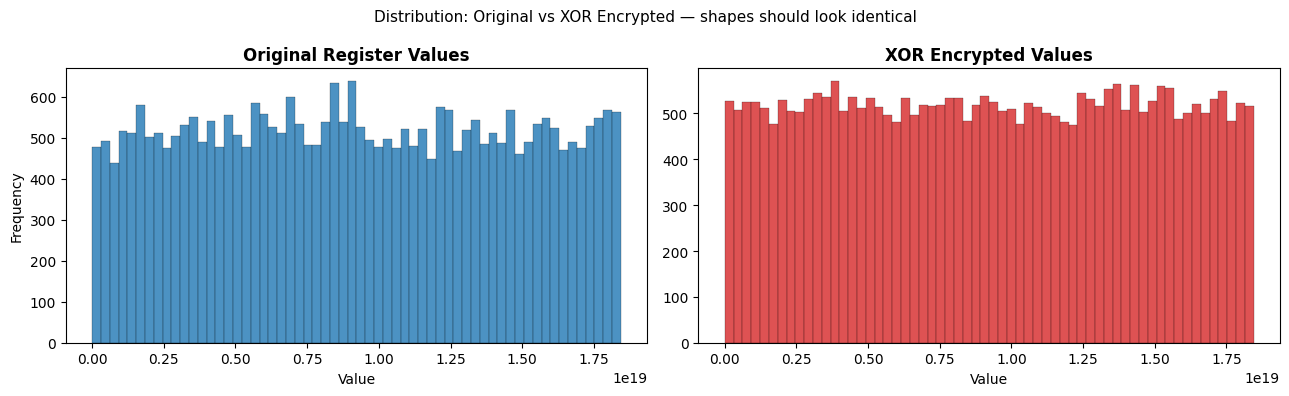


Descriptive stats comparison:
  FC1_  original mean=32833.9  encrypted mean=32799.8
  FC2_  original mean=32781.7  encrypted mean=32925.9
  FC3_  original mean=32582.9  encrypted mean=32644.7
  FC4_  original mean=32806.0  encrypted mean=32840.6

The means will differ — that is expected and intended.
The SHAPE of the distribution (uniform) is preserved.


In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(X_original.flatten(), bins=60,
             color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=0.2)
axes[0].set_title('Original Register Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Frequency')

axes[1].hist(X_encrypted.flatten(), bins=60,
             color='#d62728', alpha=0.8, edgecolor='black', linewidth=0.2)
axes[1].set_title('XOR Encrypted Values', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Value')

plt.suptitle('Distribution: Original vs XOR Encrypted — shapes should look identical',
             fontsize=11)
plt.tight_layout()
plt.show()

print('\nDescriptive stats comparison:')
for col in FC_COLS:
    orig_mean = df_original[col].mean()
    enc_mean  = df_enc[col].mean()
    print(f'  {col[:4]}  original mean={orig_mean:.1f}  encrypted mean={enc_mean:.1f}')
print()
print('The means will differ — that is expected and intended.')
print('The SHAPE of the distribution (uniform) is preserved.')

## Step 4 — XOR Decrypt

In [25]:
# Load encrypted file (simulates cloud-side receiving it)
df_to_decrypt = pd.read_csv(ENCRYPTED_FILE)

# Extract 4 encrypted columns as uint16
ec1 = df_to_decrypt['FC1_Read_Input_Register'].values.astype(np.uint16)
ec2 = df_to_decrypt['FC2_Read_Discrete_Value'].values.astype(np.uint16)
ec3 = df_to_decrypt['FC3_Read_Holding_Register'].values.astype(np.uint16)
ec4 = df_to_decrypt['FC4_Read_Coil'].values.astype(np.uint16)

# Pack encrypted 4 × 16-bit values back into 1 × 64-bit value
X_enc_loaded = (ec1.astype(np.uint64) << 48) | (ec2.astype(np.uint64) << 32) | (ec3.astype(np.uint64) << 16) | ec4.astype(np.uint64)

# Regenerate SAME key stream with same seed
rng = np.random.default_rng(SHARED_SECRET)
key_stream_decrypt = rng.integers(
    low=0,
    high=MODBUS_MAX,
    size=len(X_enc_loaded),
    dtype=np.uint64,
    endpoint=True,  # include MODBUS_MAX
)

# XOR again -> self-inverse operation (unpacks during decryption)
X_decrypted = np.bitwise_xor(X_enc_loaded, key_stream_decrypt)

# Unpack 64-bit decrypted value back to 4 × 16-bit values
dc1 = ((X_decrypted >> 48) & 0xFFFF).astype(np.uint16)
dc2 = ((X_decrypted >> 32) & 0xFFFF).astype(np.uint16)
dc3 = ((X_decrypted >> 16) & 0xFFFF).astype(np.uint16)
dc4 = (X_decrypted & 0xFFFF).astype(np.uint16)

df_dec = df_to_decrypt.copy()
df_dec['FC1_Read_Input_Register'] = dc1.astype(int)
df_dec['FC2_Read_Discrete_Value'] = dc2.astype(int)
df_dec['FC3_Read_Holding_Register'] = dc3.astype(int)
df_dec['FC4_Read_Coil'] = dc4.astype(int)

df_dec.to_csv(DECRYPTED_FILE, index=False)

print(f'Decrypted and saved -> {DECRYPTED_FILE}')
print('Pack/XOR/Unpack process:')
print(f'  4 × uint16 → 1 × uint64 → XOR with key → unpack to 4 × uint16')

Decrypted and saved -> data_xor_decrypted64onecell.csv
Pack/XOR/Unpack process:
  4 × uint16 → 1 × uint64 → XOR with key → unpack to 4 × uint16


## Step 5 — Verify Perfect Restoration

RESTORATION VERIFICATION
  Max error        : 0
  Mean error       : 0.0
  Perfect match    : True
  Total cells      : 124,424
  Mismatched cells : 0

✅ RESULT: 100% perfect restoration. Zero data loss.


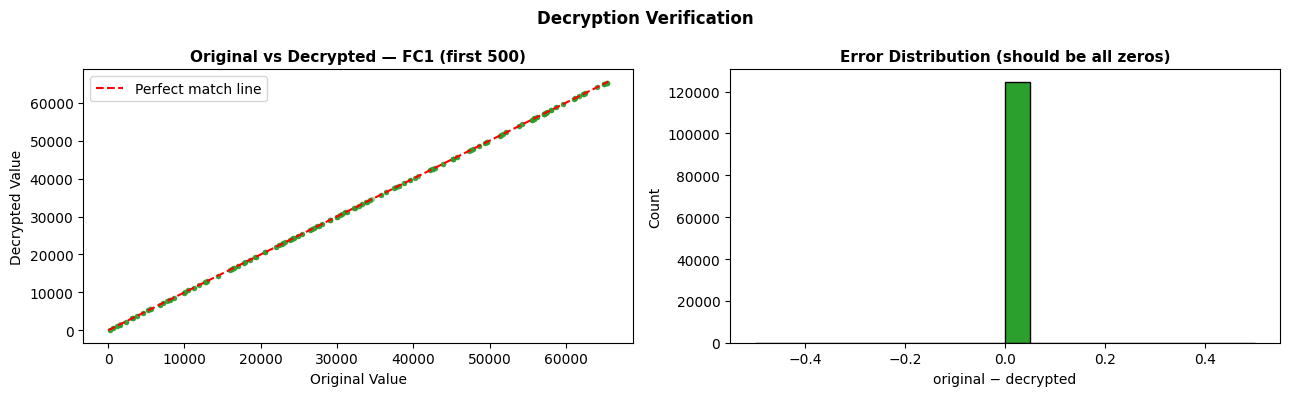

In [26]:
# Compare original vs decrypted value-by-value
X_orig_check = df_original[FC_COLS].values.astype(int)
X_dec_check  = df_dec[FC_COLS].values.astype(int)

max_error  = np.abs(X_orig_check - X_dec_check).max()
mean_error = np.abs(X_orig_check - X_dec_check).mean()
exact_match = np.array_equal(X_orig_check, X_dec_check)

print('=' * 50)
print('RESTORATION VERIFICATION')
print('=' * 50)
print(f'  Max error        : {max_error}')
print(f'  Mean error       : {mean_error}')
print(f'  Perfect match    : {exact_match}')
print(f'  Total cells      : {X_orig_check.size:,}')
print(f'  Mismatched cells : {(X_orig_check != X_dec_check).sum()}')
print('=' * 50)

if exact_match:
    print('\n✅ RESULT: 100% perfect restoration. Zero data loss.')
else:
    print('\n⚠ Mismatch detected — check seed or dtype.')

# Visual confirmation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(X_orig_check[:500, 0], X_dec_check[:500, 0],
                alpha=0.4, s=8, color='#2ca02c')
axes[0].plot([0, 65535], [0, 65535], 'r--', linewidth=1.5,
             label='Perfect match line')
axes[0].set_title('Original vs Decrypted — FC1 (first 500)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Original Value'); axes[0].set_ylabel('Decrypted Value')
axes[0].legend()

diff = X_orig_check.flatten() - X_dec_check.flatten()
axes[1].hist(diff, bins=20, color='#2ca02c', edgecolor='black')
axes[1].set_title('Error Distribution (should be all zeros)',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('original − decrypted')
axes[1].set_ylabel('Count')

plt.suptitle('Decryption Verification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — Summary

In [27]:
print('FILES PRODUCED')
print('-' * 45)
print(f'  {ENCRYPTED_FILE:<35} ← send to attacker notebook')
print(f'  {DECRYPTED_FILE:<35} ← send to cloud notebook')
print()
print('NEXT STEPS')
print('-' * 45)
print('  1. Run analysis_pipeline.ipynb on data_xor_encrypted.csv')
print('     → attacker accuracy should be ~50% (privacy proven)')
print()
print('  2. Run analysis_pipeline.ipynb on data_xor_decrypted.csv')
print('     → accuracy should match original baseline (utility proven)')

FILES PRODUCED
---------------------------------------------
  data_xor_encrypted64onecell.csv     ← send to attacker notebook
  data_xor_decrypted64onecell.csv     ← send to cloud notebook

NEXT STEPS
---------------------------------------------
  1. Run analysis_pipeline.ipynb on data_xor_encrypted.csv
     → attacker accuracy should be ~50% (privacy proven)

  2. Run analysis_pipeline.ipynb on data_xor_decrypted.csv
     → accuracy should match original baseline (utility proven)
